In [1]:

import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
recipes = pd.read_csv('../data/RAW_recipes.csv')
interactions = pd.read_csv('../data/RAW_interactions.csv')

print('Recipes shape:', recipes.shape)
print('Interactions shape:', interactions.shape)
recipes.head()

Recipes shape: (83782, 12)
Interactions shape: (731927, 5)


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,1 brownies in the world best ever,333281,40,985201,2008-10-27,"['60-minutes-or-less', 'time-to-make', 'course...","[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]",10,['heat the oven to 350f and arrange the rack i...,"these are the most; chocolatey, moist, rich, d...","['bittersweet chocolate', 'unsalted butter', '...",9
1,1 in canada chocolate chip cookies,453467,45,1848091,2011-04-11,"['60-minutes-or-less', 'time-to-make', 'cuisin...","[595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]",12,"['pre-heat oven the 350 degrees f', 'in a mixi...",this is the recipe that we use at my school ca...,"['white sugar', 'brown sugar', 'salt', 'margar...",11
2,412 broccoli casserole,306168,40,50969,2008-05-30,"['60-minutes-or-less', 'time-to-make', 'course...","[194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]",6,"['preheat oven to 350 degrees', 'spray a 2 qua...",since there are already 411 recipes for brocco...,"['frozen broccoli cuts', 'cream of chicken sou...",9
3,millionaire pound cake,286009,120,461724,2008-02-12,"['time-to-make', 'course', 'cuisine', 'prepara...","[878.3, 63.0, 326.0, 13.0, 20.0, 123.0, 39.0]",7,"['freheat the oven to 300 degrees', 'grease a ...",why a millionaire pound cake? because it's su...,"['butter', 'sugar', 'eggs', 'all-purpose flour...",7
4,2000 meatloaf,475785,90,2202916,2012-03-06,"['time-to-make', 'course', 'main-ingredient', ...","[267.0, 30.0, 12.0, 12.0, 29.0, 48.0, 2.0]",17,"['pan fry bacon , and set aside on a paper tow...","ready, set, cook! special edition contest entr...","['meatloaf mixture', 'unsmoked bacon', 'goat c...",13


In [ ]:
##Merging the two datasets

In [3]:
merged = recipes.merge(interactions, left_on='id', right_on='recipe_id', how='left')

# Replacing 0 ratings with NaN
merged['rating'] = merged['rating'].replace(0, np.nan)

# Finding average rating per recipe
avg_ratings = merged.groupby('id')['rating'].mean()

# Adding average rating back to recipes
recipes = recipes.merge(avg_ratings.rename('avg_rating'), on='id', how='left')

print('Final recipes shape:', recipes.shape)
recipes.head()

Final recipes shape: (83782, 13)


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,avg_rating
0,1 brownies in the world best ever,333281,40,985201,2008-10-27,"['60-minutes-or-less', 'time-to-make', 'course...","[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]",10,['heat the oven to 350f and arrange the rack i...,"these are the most; chocolatey, moist, rich, d...","['bittersweet chocolate', 'unsalted butter', '...",9,4.0
1,1 in canada chocolate chip cookies,453467,45,1848091,2011-04-11,"['60-minutes-or-less', 'time-to-make', 'cuisin...","[595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]",12,"['pre-heat oven the 350 degrees f', 'in a mixi...",this is the recipe that we use at my school ca...,"['white sugar', 'brown sugar', 'salt', 'margar...",11,5.0
2,412 broccoli casserole,306168,40,50969,2008-05-30,"['60-minutes-or-less', 'time-to-make', 'course...","[194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]",6,"['preheat oven to 350 degrees', 'spray a 2 qua...",since there are already 411 recipes for brocco...,"['frozen broccoli cuts', 'cream of chicken sou...",9,5.0
3,millionaire pound cake,286009,120,461724,2008-02-12,"['time-to-make', 'course', 'cuisine', 'prepara...","[878.3, 63.0, 326.0, 13.0, 20.0, 123.0, 39.0]",7,"['freheat the oven to 300 degrees', 'grease a ...",why a millionaire pound cake? because it's su...,"['butter', 'sugar', 'eggs', 'all-purpose flour...",7,5.0
4,2000 meatloaf,475785,90,2202916,2012-03-06,"['time-to-make', 'course', 'main-ingredient', ...","[267.0, 30.0, 12.0, 12.0, 29.0, 48.0, 2.0]",17,"['pan fry bacon , and set aside on a paper tow...","ready, set, cook! special edition contest entr...","['meatloaf mixture', 'unsmoked bacon', 'goat c...",13,5.0


In [4]:
# Parse Nutrition Column

recipes['nutrition'] = recipes['nutrition'].apply(ast.literal_eval)

nutrition_cols = ['calories', 'total_fat', 'sugar', 'sodium', 
                  'protein', 'saturated_fat', 'carbohydrates']

recipes[nutrition_cols] = pd.DataFrame(
    recipes['nutrition'].tolist(), index=recipes.index
)

recipes[nutrition_cols].describe()

,calories,total_fat,sugar,sodium,protein,saturated_fat,carbohydrates
count,83782.000000,83782.000000,83782.000000,83782.000000,83782.000000,83782.000000,83782.000000
mean,429.926989,32.625409,68.664379,28.941682,33.133382,40.244277,13.786756
std,636.628493,60.148805,247.238599,144.974937,51.032986,80.912788,28.762703
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,171.325000,8.000000,9.000000,5.000000,6.000000,6.000000,4.000000
50%,305.400000,20.000000,23.000000,14.000000,18.000000,21.000000,9.000000
75%,498.700000,39.000000,61.000000,32.000000,49.000000,49.000000,16.000000
max,45609.000000,3464.000000,30260.000000,29338.000000,4356.000000,6875.000000,3007.000000


In [8]:
# Data types and converting them to datetime
print(recipes.dtypes)
recipes['submitted'] = pd.to_datetime(recipes['submitted'])

name                         str
id                         int64
minutes                    int64
contributor_id             int64
submitted         datetime64[us]
tags                         str
nutrition                 object
n_steps                    int64
steps                        str
description                  str
ingredients                  str
n_ingredients              int64
avg_rating               float64
calories                 float64
total_fat                float64
sugar                    float64
sodium                   float64
protein                  float64
saturated_fat            float64
carbohydrates            float64
dtype: object


In [9]:
# Checking for any missing values
missing = recipes.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)

Columns with missing values:
name              1
description      70
avg_rating     2609
dtype: int64


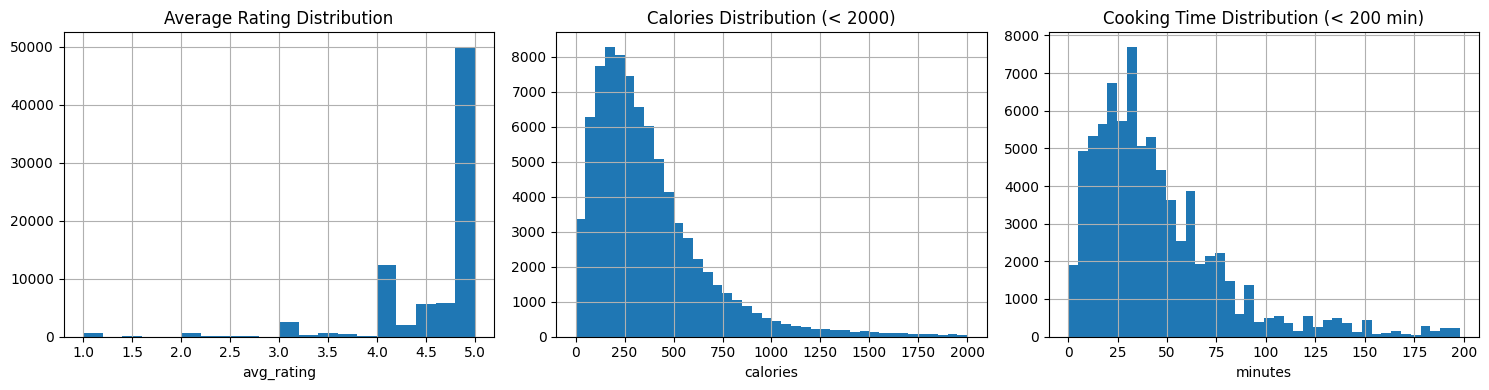

In [11]:
# Basic EDA
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
recipes['avg_rating'].dropna().hist(bins=20, ax=axes[0])
axes[0].set_title('Average Rating Distribution')
axes[0].set_xlabel('avg_rating')

# Calories distribution (cap outliers for visibility)
recipes[recipes['calories'] < 2000]['calories'].hist(bins=40, ax=axes[1])
axes[1].set_title('Calories Distribution (< 2000)')
axes[1].set_xlabel('calories')

# Cooking time distribution (cap outliers)
recipes[recipes['minutes'] < 200]['minutes'].hist(bins=40, ax=axes[2])
axes[2].set_title('Cooking Time Distribution (< 200 min)')
axes[2].set_xlabel('minutes')

plt.tight_layout()
plt.savefig('eda_distributions.png')
plt.show()

In [12]:
recipes.to_csv('../data/recipes_cleaned.csv', index=False)
print('Saved to data/recipes_cleaned.csv')

Saved to data/recipes_cleaned.csv
